In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [3]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from helpers import ( 
                    prep_the_data, 
                      export_puma_kepler, 
                          make_daily_table_for_model_with_nta,
                      load_idata,
                        make_typical_week_2025,
                        make_daily_observed_2025,
                    kepler_typical_week_from_dow_complaint,
                      compare_models_loo_waic,
                      loo_diagnostics,
                        plot_coverage_curve
                    )


import geopandas as gpd
from keplergl import KeplerGl
from pathlib import Path

In [4]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [5]:
df_puma = prep_the_data(df_puma)

In [6]:
df_puma_2022__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2022-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31") &
     (df_puma["time_of_day"] ==  "night")
].copy()


In [7]:
df_puma_2022__2024.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
3,4103,Noise,"Noise, Barking Dog",NaN,2022-08-02,night,1,MN0301,0.245574,Chinatown-Two Bridges,Tuesday,August,0,August__2022,Animal,ANIMAL__Tuesday
5,4103,Noise,"Noise, Barking Dog",NaN,2022-08-22,night,1,MN0301,0.245574,Chinatown-Two Bridges,Monday,August,0,August__2022,Animal,ANIMAL__Monday
6,4103,Noise,"Noise, Barking Dog",NaN,2022-08-27,night,1,MN0301,0.245574,Chinatown-Two Bridges,Saturday,August,1,August__2022,Animal,ANIMAL__Saturday
8,4103,Noise,"Noise, Barking Dog",NaN,2023-06-02,night,1,MN0301,0.245574,Chinatown-Two Bridges,Friday,June,0,June__2023,Animal,ANIMAL__Friday
10,4103,Noise,"Noise, Barking Dog",NaN,2023-06-12,night,1,MN0301,0.245574,Chinatown-Two Bridges,Monday,June,0,June__2023,Animal,ANIMAL__Monday


In [8]:
COMPLAINT = "Social / Party"
# COMPLAINT = "Animal"
# COMPLAINT = "Construction / Industrial"
# COMPLAINT = "Mechanical Equipment"

# Rebuild daily_df_train exactly as in training
daily_df_train, coords = make_daily_table_for_model_with_nta(
    df_puma_2022__2024,
    complaint_value=COMPLAINT,
)



In [9]:
# Rebuild puma → nta mapping
puma_nta_map = (
    daily_df_train[["puma_idx", "nta_idx"]]
    .drop_duplicates()
    .sort_values("puma_idx")
)


In [10]:

puma_to_nta_idx = puma_nta_map["nta_idx"].to_numpy()


In [11]:
idata_nta = load_idata("../data/processed/models/model3_nta_idata.nc")

✅ Loaded idata <- ../data/processed/models/model3_nta_idata.nc


In [12]:
lam_post = idata_nta.posterior["lam"]

# Posterior mean forecast
df_forecast = (
    lam_post
    .mean(dim=("chain", "draw"))
    .to_dataframe(name="lam_forecast")
    .reset_index()
)


In [13]:
hdi = az.hdi(lam_post, hdi_prob=0.9)["lam"]

hdi_df = (
    hdi.to_dataframe(name="lam_hdi")
       .reset_index()
       .pivot_table(
           index=["puma", "dow"],
           columns="hdi",
           values="lam_hdi",
       )
       .reset_index()
       .rename(columns={"lower": "lam_low_90", "higher": "lam_high_90"})
)

df_forecast = df_forecast.merge(hdi_df, on=["puma", "dow"], how="left")
df_forecast["lam_width_90"] = (
    df_forecast["lam_high_90"] - df_forecast["lam_low_90"]
)


In [14]:
df_puma_311_2025 = df_puma.loc[
    (df_puma["created_bucket"] >= "2025-01-01") &
     (df_puma["time_of_day"] ==  "night")
].copy()


In [15]:
df_puma_311_2025.head()


,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
50,4103,Noise,"Noise, Barking Dog",NaN,2025-06-17,night,1,MN0301,0.245574,Chinatown-Two Bridges,Tuesday,June,0,June__2025,Animal,ANIMAL__Tuesday
53,4103,Noise,"Noise, Barking Dog",NaN,2025-07-04,night,1,MN0301,0.245574,Chinatown-Two Bridges,Friday,July,0,July__2025,Animal,ANIMAL__Friday
55,4103,Noise,"Noise, Barking Dog",NaN,2025-07-16,night,1,MN0301,0.245574,Chinatown-Two Bridges,Wednesday,July,0,July__2025,Animal,ANIMAL__Wednesday
57,4103,Noise,"Noise, Barking Dog",NaN,2025-07-26,night,1,MN0301,0.245574,Chinatown-Two Bridges,Saturday,July,1,July__2025,Animal,ANIMAL__Saturday
60,4103,Noise,"Noise, Barking Dog",NaN,2025-08-17,night,2,MN0301,0.245574,Chinatown-Two Bridges,Sunday,August,1,August__2025,Animal,ANIMAL__Sunday


In [16]:
typical_2025 = make_typical_week_2025(
    df_puma_311_2025,
    complaint_col="descriptor_group"
)


In [17]:
cmp_2025_model3 = (
    df_forecast
    .merge(typical_2025, on=["puma", "dow"], how="left")
)

cmp_2025_model3["error"] = cmp_2025_model3["observed_2025"] - cmp_2025_model3["lam_forecast"]
cmp_2025_model3["abs_error"] = cmp_2025_model3["error"].abs()

cmp_2025_model3["within_90"] = (
    (cmp_2025_model3["observed_2025"] >= cmp_2025_model3["lam_low_90"]) &
    (cmp_2025_model3["observed_2025"] <= cmp_2025_model3["lam_high_90"])
)


In [18]:
print(f"MAE: {cmp_2025_model3["abs_error"].mean()}")
print(f"Median AE: {cmp_2025_model3["abs_error"].median()}")
print(f"90% Coverage: {cmp_2025_model3["within_90"].mean()}")

MAE: 4.78783948459442
Median AE: 2.862046571591094
90% Coverage: 0.2051948051948052


In [19]:

# -----------------------------
# 0) Daily observed (summer 2025)
# -----------------------------
daily_2025 = make_daily_observed_2025(
    df_puma_311_2025,
    complaint_value=COMPLAINT,          # or None
    complaint_col="descriptor_group",
)



In [20]:
# -----------------------------
# 1) Merge forecast (keyed by puma,dow)
#    Use df_forecast_week if that's your current object.
# -----------------------------
forecast = df_forecast_week if "df_forecast_week" in globals() else df_forecast

daily_cmp_2025_model3 = daily_2025.merge(
    forecast,
    on=["puma", "dow"],
    how="left",
)

# -----------------------------
# 2) Comparison columns (point forecast errors)
# -----------------------------
daily_cmp_2025_model3["error"] = (
    daily_cmp_2025_model3["daily_count"] - daily_cmp_2025_model3["lam_forecast"]
)
daily_cmp_2025_model3["abs_error"] = daily_cmp_2025_model3["error"].abs()

# Mean-rate interval coverage (NOT predictive)
if {"lam_low_90", "lam_high_90"}.issubset(daily_cmp_2025_model3.columns):
    daily_cmp_2025_model3["within_90_lam"] = (
        (daily_cmp_2025_model3["daily_count"] >= daily_cmp_2025_model3["lam_low_90"]) &
        (daily_cmp_2025_model3["daily_count"] <= daily_cmp_2025_model3["lam_high_90"])
    )
else:
    daily_cmp_2025_model3["within_90_lam"] = pd.NA

# -----------------------------
# 3) Build puma_idx / dow_idx aligned to training coords
# -----------------------------
puma_to_idx = {str(p): i for i, p in enumerate(coords["puma"])}
dow_to_idx  = {str(d): i for i, d in enumerate(coords["dow"])}

daily_cmp_2025_model3["puma_idx"] = daily_cmp_2025_model3["puma"].astype(str).map(puma_to_idx)
daily_cmp_2025_model3["dow_idx"]  = daily_cmp_2025_model3["dow"].astype(str).map(dow_to_idx)

# Drop any rows not present in training coords
daily_cmp_2025_model3 = daily_cmp_2025_model3.dropna(subset=["puma_idx", "dow_idx"]).copy()
daily_cmp_2025_model3["puma_idx"] = daily_cmp_2025_model3["puma_idx"].astype(int)
daily_cmp_2025_model3["dow_idx"]  = daily_cmp_2025_model3["dow_idx"].astype(int)

# -----------------------------
# 4) Posterior predictive draws for Model 3 (Poisson)
# -----------------------------
lam_draws_m3 = (
    idata_nta.posterior["lam"]
    .stack(sample=("chain", "draw"))
    .values
)  # shape: (n_puma, n_dow, S)

p_idx = daily_cmp_2025_model3["puma_idx"].to_numpy()
d_idx = daily_cmp_2025_model3["dow_idx"].to_numpy()

mu_draws_m3 = lam_draws_m3[p_idx, d_idx, :]  # (n_days, S)

rng = np.random.default_rng(42)
y_pp_model3 = rng.poisson(mu_draws_m3)       # (n_days, S)


In [21]:

# Stack posterior draws
lam_draws_m3 = (
    idata_nta.posterior["lam"]
    .stack(sample=("chain", "draw"))
    .values
)  # shape: (n_puma, n_dow, S)

# Select lam draws per 2025 day
p_idx = daily_cmp_2025_model3["puma_idx"].to_numpy()
d_idx = daily_cmp_2025_model3["dow_idx"].to_numpy()

mu_draws_m3 = lam_draws_m3[p_idx, d_idx, :]  # (n_days, S)

# Poisson posterior predictive
rng = np.random.default_rng(42)
y_pp_model3 = rng.poisson(mu_draws_m3)

In [22]:
gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
    daily_cmp_2025_model3,
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    out_path="../data/processed/kepler/model3_daily_forecast_vs_2025.geojson",
)


✅ Kepler GeoJSON written to: ../data/processed/kepler/model3_daily_forecast_vs_2025.geojson


In [23]:
daily_df, coords = make_daily_table_for_model_with_nta(
    df_puma_2022__2024,
    complaint_col="descriptor_group",
)

In [24]:
# daily_df has: puma, nta_name, puma_idx, nta_idx, dow_idx, daily_count

# Build a unique mapping: puma_idx -> nta_idx
puma_nta_map = (
    daily_df[["puma_idx", "nta_idx"]]
    .drop_duplicates()
    .sort_values("puma_idx")
)

# sanity check: each puma maps to exactly 1 nta
assert puma_nta_map["puma_idx"].is_unique, "A PUMA maps to multiple NTAs (check your join)."

puma_to_nta_idx = puma_nta_map["nta_idx"].to_numpy()  # shape (n_puma,)


In [27]:
# -----------------------------
# Data for the model
# -----------------------------
y = daily_df["daily_count"].to_numpy(dtype=int)
puma_idx_obs = daily_df["puma_idx"].to_numpy(dtype=int)
dow_idx_obs  = daily_df["dow_idx"].to_numpy(dtype=int)
year_idx_obs= daily_df["year_idx"].to_numpy(dtype=int)

In [28]:
# with pm.Model(coords=coords) as m_nb_min_upgrade:

#     mu_nta = pm.Normal("mu_nta", mu=0.0, sigma=1.5, dims=("nta","dow"))

#     sigma_puma = pm.Exponential("sigma_puma", 2.0)  # tighter than 1.0
#     delta_puma = pm.Normal("delta_puma", 0.0, sigma_puma, dims=("puma","dow"))

#     log_lambda = pm.Deterministic(
#         "log_lambda",
#         mu_nta[puma_to_nta_idx, :] + delta_puma,
#         dims=("puma","dow"),
#     )
#     lam = pm.Deterministic("lam", pm.math.exp(log_lambda), dims=("puma","dow"))

#     # dispersion by day-of-week
#     alpha_dow = pm.Exponential("alpha_dow", 1.0, dims=("dow",))

#     y_obs = pm.NegativeBinomial(
#         "y_obs",
#         mu=lam[puma_idx_obs, dow_idx_obs],
#         alpha=alpha_dow[dow_idx_obs],
#         observed=y,
#     )

#     idata_nta_nb = pm.sample(
#         draws=1000,
#         tune=1000,
#         chains=4,
#         target_accept=0.9,
#         random_seed=42,
#         idata_kwargs={"log_likelihood": True},
#     )


with pm.Model(coords=coords) as m_nb_year:

    # -----------------------------
    # NTA-level weekday baseline (log scale)
    # -----------------------------
    mu_nta = pm.Normal("mu_nta", mu=0.0, sigma=1.5, dims=("nta", "dow"))

    # -----------------------------
    # PUMA-level deviation (partial pooling) by dow
    # -----------------------------
    sigma_puma = pm.Exponential("sigma_puma", 2.0)  # tighter for stability
    delta_puma = pm.Normal(
        "delta_puma",
        mu=0.0,
        sigma=sigma_puma,
        dims=("puma", "dow"),
    )

    # -----------------------------
    # Base (puma, dow) log-rate grid
    # -----------------------------
    log_lambda = pm.Deterministic(
        "log_lambda",
        mu_nta[puma_to_nta_idx, :] + delta_puma,
        dims=("puma", "dow"),
    )

    # -----------------------------
    # Year-level mean shift (partial pooling)
    # -----------------------------
    sigma_year = pm.Exponential("sigma_year", 1.0)
    year_offset = pm.Normal("year_offset", 0.0, sigma=sigma_year, dims=("year",))

    # -----------------------------
    # Observation-level log-mean / mean
    # -----------------------------
    log_mu_obs = log_lambda[puma_idx_obs, dow_idx_obs] + year_offset[year_idx_obs]
    mu_obs = pm.Deterministic("mu_obs", pm.math.exp(log_mu_obs), dims=("obs",))

    # -----------------------------
    # Dispersion by day-of-week
    # Var(Y) = mu + mu^2/alpha
    # -----------------------------
    alpha_dow = pm.Exponential("alpha_dow", 1.0, dims=("dow",))

    # -----------------------------
    # Likelihood
    # -----------------------------
    y_obs = pm.NegativeBinomial(
        "y_obs",
        mu=mu_obs,
        alpha=alpha_dow[dow_idx_obs],
        observed=y,
    )

    idata_nta_nb = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.94,
        random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_nta, sigma_puma, delta_puma, sigma_year, year_offset, alpha_dow]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 530 seconds.
There were 10 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [30]:
loo_table, waic_table = compare_models_loo_waic(idata_nta_nb, idata_nta, m2_name="Model 4 (NTA pooled + NB)", m3_name="Model 3 (NTA pooled, Poisson)")


/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/Users/mozilla/Library/Caches/pypoetry/virtualenvs/nyc-311-bayesian-noise-models-pweGKFeb-py3.12/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 4 (NTA pooled + NB),0,-48347.142126,486.835962,0.000000,0.904321,160.824183,0.000000,True,log
"Model 3 (NTA pooled, Poisson)",1,-82652.068642,3266.777872,34304.926516,0.095679,3210.169261,3096.541903,True,log


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Model 4 (NTA pooled + NB),0,-48350.005922,489.699757,0.000000,0.904264,162.199332,0.000000,True,log
"Model 3 (NTA pooled, Poisson)",1,-83403.445357,4018.154587,35053.439435,0.095736,3572.244877,3458.812717,True,log


In [32]:

# # --- Posterior lam[puma, dow]
# lam_post = idata_nta_nb.posterior["lam"]

# # Posterior mean of lam
# df_forecast_week = (
#     lam_post.mean(dim=("chain", "draw"))
#             .to_dataframe(name="lam_forecast")
#             .reset_index()
# )

# # 90% HDI for lam (uncertainty in the mean rate)
# hdi = az.hdi(lam_post, hdi_prob=0.9)["lam"]
# hdi_df = (
#     hdi.to_dataframe(name="lam_hdi")
#        .reset_index()
#        .pivot_table(index=["puma", "dow"], columns="hdi", values="lam_hdi")
#        .reset_index()
#        .rename(columns={"lower": "lam_low_90", "higher": "lam_high_90"})
# )

# df_forecast_week = df_forecast_week.merge(hdi_df, on=["puma", "dow"], how="left")
# df_forecast_week["lam_width_90"] = df_forecast_week["lam_high_90"] - df_forecast_week["lam_low_90"]



post = idata_nta_nb.posterior

# If lam is missing, reconstruct it from log_lambda
if "lam" in post:
    lam_post = post["lam"]  # (chain, draw, puma, dow)
else:
    # log_lambda is (chain, draw, puma, dow)
    lam_post = np.exp(post["log_lambda"])

# Posterior mean of lam
df_forecast_week = (
    lam_post.mean(dim=("chain", "draw"))
            .to_dataframe()
            .reset_index()
            .rename(columns={lam_post.name if hasattr(lam_post, "name") else 0: "lam_forecast"})
)

# 90% HDI for lam
hdi = az.hdi(lam_post, hdi_prob=0.9)  # returns DataArray with dim "hdi"

# Convert HDI to columns
lam_low = hdi.sel(hdi="lower").to_dataframe().reset_index()
lam_high = hdi.sel(hdi="higher").to_dataframe().reset_index()

# The value column name is not stable; rename it robustly
valcol_low = [c for c in lam_low.columns if c not in ("puma", "dow")][0]
valcol_high = [c for c in lam_high.columns if c not in ("puma", "dow")][0]
lam_low = lam_low.rename(columns={valcol_low: "lam_low_90"})
lam_high = lam_high.rename(columns={valcol_high: "lam_high_90"})

df_forecast_week = (
    df_forecast_week
    .merge(lam_low[["puma", "dow", "lam_low_90"]], on=["puma", "dow"], how="left")
    .merge(lam_high[["puma", "dow", "lam_high_90"]], on=["puma", "dow"], how="left")
)
df_forecast_week["lam_width_90"] = df_forecast_week["lam_high_90"] - df_forecast_week["lam_low_90"]


In [49]:
# # Compare Model (forecast) vs observed 2025 typical week
# cmp_2025_model4 = (
#     df_forecast_week
#     .merge(typical_2025, on=["puma", "dow"], how="left")
# )

# # Errors vs forecast mean
# cmp_2025_model4["error"] = cmp_2025_model4["observed_2025"] - cmp_2025_model4["lam_forecast"]
# cmp_2025_model4["abs_error"] = cmp_2025_model4["error"].abs()

# # Coverage of the *lam* interval (rate uncertainty, not full predictive uncertainty)
# cmp_2025_model4["within_90_lam"] = (
#     (cmp_2025_model4["observed_2025"] >= cmp_2025_model4["lam_low_90"]) &
#     (cmp_2025_model4["observed_2025"] <= cmp_2025_model4["lam_high_90"])
# )

# # Optional: summarize
# summary = {
#     "MAE": float(cmp_2025_model4["abs_error"].mean()),
#     "Median AE": float(cmp_2025_model4["abs_error"].median()),
#     "90% Coverage (lam interval)": float(cmp_2025_model4["within_90_lam"].mean()),
# }
# summary

import numpy as np
import pandas as pd
import numpy as np
import pandas as pd

import numpy as np
import pandas as pd

def score_against_real_2025_days(
    *,
    daily_2025: pd.DataFrame,
    idata,
    coords: dict,
    year_fallback: str = "nearest",   # "nearest" | "zero" | "error"
    hdi_prob: float = 0.90,
    random_seed: int = 42,
):
    df = daily_2025.copy()

    # -----------------------------
    # 1) Hygiene
    # -----------------------------
    df["puma"] = df["puma"].astype(str).str.strip()
    df["dow"]  = df["dow"].astype(str).str.strip()
    df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.normalize()
    df = df[df["date"].notna()].copy()
    df["year"] = df["date"].dt.year.astype(int)

    # -----------------------------
    # 2) Index maps
    # -----------------------------
    puma_to_idx = {str(p): i for i, p in enumerate(coords["puma"])}
    dow_to_idx  = {str(d): i for i, d in enumerate(coords["dow"])}

    df["puma_idx"] = df["puma"].map(puma_to_idx)
    df["dow_idx"]  = df["dow"].map(dow_to_idx)

    df = df.dropna(subset=["puma_idx", "dow_idx"]).copy()
    df["puma_idx"] = df["puma_idx"].astype(int)
    df["dow_idx"]  = df["dow_idx"].astype(int)

    # Year mapping if the model has year coords
    has_year = "year" in coords and coords["year"] is not None and len(coords["year"]) > 0
    if has_year:
        year_labels = [int(y) for y in coords["year"]]
        year_to_idx = {int(y): i for i, y in enumerate(year_labels)}

        def map_year(y):
            if y in year_to_idx:
                return year_to_idx[y]
            if year_fallback == "nearest":
                nearest = min(year_labels, key=lambda t: abs(t - y))
                return year_to_idx[nearest]
            if year_fallback == "zero":
                return None
            if year_fallback == "error":
                return None
            raise ValueError("year_fallback must be nearest|zero|error")

        df["year_idx"] = df["year"].map(map_year)
    else:
        df["year_idx"] = None

    # Date mapping if the model has date coords (day_shock)
    has_date = "date" in coords and coords["date"] is not None and len(coords["date"]) > 0
    if has_date:
        # Normalize coord dates to Timestamp for mapping
        coord_dates = pd.to_datetime(coords["date"]).normalize()
        date_to_idx = {pd.Timestamp(d): i for i, d in enumerate(coord_dates)}
        df["date_idx"] = df["date"].map(date_to_idx)
    else:
        df["date_idx"] = None

    # -----------------------------
    # 3) Pull posterior draws
    # -----------------------------
    post = idata.posterior

    # Baseline log_lambda(puma,dow)
    log_lambda_draws = (
        post["log_lambda"]
        .stack(sample=("chain", "draw"))
        .transpose("puma", "dow", "sample")
        .values
    )  # (n_puma, n_dow, S)
    S = log_lambda_draws.shape[-1]

    # Dispersion alpha_dow(dow)
    alpha_dow_draws = (
        post["alpha_dow"]
        .stack(sample=("chain", "draw"))
        .transpose("dow", "sample")
        .values
    )  # (n_dow, S)

    # Optional year_offset(year)
    has_year_offset = "year_offset" in post.data_vars

    if has_year_offset:
        year_offset_draws = (
            post["year_offset"]
            .stack(sample=("chain", "draw"))
            .transpose("year", "sample")
            .values
        )  # (n_year, S)

    # Optional day_shock(date)
    has_day_shock = "day_shock" in post.data_vars
    if has_day_shock:
        day_shock_draws = (
            post["day_shock"]
            .stack(sample=("chain", "draw"))
            .transpose("date", "sample")
            .values
        )  # (n_date, S)

    # -----------------------------
    # 4) Build log-mu per row
    # -----------------------------
    p_idx = df["puma_idx"].to_numpy()
    d_idx = df["dow_idx"].to_numpy()

    log_mu = log_lambda_draws[p_idx, d_idx, :]  # (n_rows, S)

    # Add year offset if model has it
    if has_year_offset:
        if df["year_idx"].isna().any() or df["year_idx"].iloc[0] is None:
            if year_fallback == "zero":
                # missing year -> 0 effect
                pass
            else:
                # If nearest mapping was requested but coords missing, drop those rows
                df = df[df["year_idx"].notna()].copy()
                p_idx = df["puma_idx"].to_numpy()
                d_idx = df["dow_idx"].to_numpy()
                log_mu = log_lambda_draws[p_idx, d_idx, :]

        if len(df) > 0 and df["year_idx"].notna().all():
            y_idx = df["year_idx"].astype(int).to_numpy()
            log_mu = log_mu + year_offset_draws[y_idx, :]

    # Add day shock if model has it
    if has_day_shock:
        df = df[df["date_idx"].notna()].copy()
        p_idx = df["puma_idx"].to_numpy()
        d_idx = df["dow_idx"].to_numpy()
        log_mu = log_lambda_draws[p_idx, d_idx, :]

        # re-add year offset if applicable after filtering
        if has_year_offset and len(df) > 0 and df["year_idx"].notna().all():
            y_idx = df["year_idx"].astype(int).to_numpy()
            log_mu = log_mu + year_offset_draws[y_idx, :]

        t_idx = df["date_idx"].astype(int).to_numpy()
        log_mu = log_mu + day_shock_draws[t_idx, :]

    mu_draws = np.exp(log_mu)
    df["mu_pred_mean"] = mu_draws.mean(axis=1)

    # alpha per row (based on dow)
    alpha_draws = alpha_dow_draws[d_idx, :]  # (n_rows, S)

    # -----------------------------
    # 5) Posterior predictive y draws (NB via Gamma–Poisson)
    # -----------------------------
    rng = np.random.default_rng(random_seed)

    rate = alpha_draws / np.clip(mu_draws, 1e-9, None)
    lam_day = rng.gamma(shape=alpha_draws, scale=1.0 / rate)
    y_pp = rng.poisson(lam_day)

    lo = (1.0 - hdi_prob) / 2
    hi = 1.0 - lo
    df["y_pred_low_90"]  = np.quantile(y_pp, lo, axis=1)
    df["y_pred_high_90"] = np.quantile(y_pp, hi, axis=1)

    df["within_90_pred"] = (
        (df["daily_count"] >= df["y_pred_low_90"]) &
        (df["daily_count"] <= df["y_pred_high_90"])
    )

    df["error"] = df["daily_count"] - df["mu_pred_mean"]
    df["abs_error"] = df["error"].abs()

    summary = {
        "MAE": float(df["abs_error"].mean()),
        "Median AE": float(df["abs_error"].median()),
        "90% Coverage (predictive)": float(df["within_90_pred"].mean()),
        "N_days": int(len(df)),
        "used_year_offset": bool(has_year_offset),
        "used_day_shock": bool(has_day_shock),
    }

    return df, y_pp, summary



scored_2025, y_pp_model4_2025, summary_2025 = score_against_real_2025_days(
    daily_2025=daily_2025,          # must have puma,dow,date,daily_count
    idata=idata_nta_nb,             # your fitted year-aware NB model idata
    coords=coords,                  # training coords (includes "year")
    year_fallback="nearest",          # use "nearest" if 2025 not in coords["year"]
)

summary_2025


{'MAE': 9.5439303393241,
 'Median AE': 6.023554230241076,
 '90% Coverage (predictive)': 0.9157698675496688,
 'N_days': 4832,
 'used_year_offset': True,
 'used_day_shock': False}

In [56]:
import numpy as np



def crps_from_draws(y_pp, y_obs, *, pair_subsample=256, seed=42):
    """
    Approximate CRPS per row using posterior predictive draws.

    y_pp: (N, S) draws
    y_obs: (N,) observed
    pair_subsample: use K draws to approximate E|X-X'| term
    """
    rng = np.random.default_rng(seed)
    N, S = y_pp.shape
    y_obs = np.asarray(y_obs).reshape(-1,)

    # term1 = E|X - y|
    term1 = np.mean(np.abs(y_pp - y_obs[:, None]), axis=1)

    # term2 = 0.5 * E|X - X'|
    K = min(pair_subsample, S)
    idx = rng.choice(S, size=K, replace=False)
    xs = y_pp[:, idx]  # (N, K)

    # Efficient pairwise absolute differences: sort trick
    xs_sorted = np.sort(xs, axis=1)
    # E|X-X'| for sample-based distribution:
    # 2/(K^2) * sum_{i} (2i-K-1)*x_i  (for sorted x_i), then take abs already via ordering
    weights = (2*np.arange(1, K+1) - K - 1).astype(float)  # (K,)
    sum_weighted = np.sum(xs_sorted * weights[None, :], axis=1)
    e_abs_xx = (2.0 / (K*K)) * sum_weighted

    crps = term1 - 0.5 * e_abs_xx
    return crps

# Usage
y_obs = scored_2025["daily_count"].to_numpy()
crps = crps_from_draws(y_pp_model4_2025, y_obs, pair_subsample=256)

crps_summary = {
    "mean_CRPS": float(np.mean(crps)),
    "median_CRPS": float(np.median(crps)),
}
crps_summary


def elpd_from_draws(y_pp, y_obs, *, smoothing=1.0):
    """
    Estimate expected log predictive density from posterior predictive draws.

    Uses an empirical pmf from draws with additive smoothing:
      p(y) = (count(y) + smoothing) / (S + smoothing * (support_size))

    Returns: (elpd_total, elpd_mean, lpd_per_row)
    """
    y_obs = np.asarray(y_obs).astype(int)
    N, S = y_pp.shape

    lpd = np.empty(N, dtype=float)

    for i in range(N):
        draws = y_pp[i, :].astype(int)

        # empirical counts
        vals, counts = np.unique(draws, return_counts=True)
        count_map = dict(zip(vals, counts))

        # define support size as unique vals in draws plus the observed value
        support_vals = set(vals.tolist() + [int(y_obs[i])])
        K = len(support_vals)

        c = count_map.get(int(y_obs[i]), 0)
        p = (c + smoothing) / (S + smoothing * K)

        lpd[i] = np.log(p)

    elpd_total = float(np.sum(lpd))
    elpd_mean = float(np.mean(lpd))
    return elpd_total, elpd_mean, lpd

# Usage
y_obs = scored_2025["daily_count"].to_numpy().astype(int)
elpd_total, elpd_mean, lpd = elpd_from_draws(y_pp_model4_2025, y_obs, smoothing=1.0)

elpd_summary = {
    "ELPD_total": elpd_total,
    "ELPD_mean": elpd_mean,  # per-row average log score
}
elpd_summary


{'ELPD_total': -17106.035414662285, 'ELPD_mean': -3.5401563358158703}

In [57]:
def summarize_forecast_metrics(
    df,
    y_pp,
    *,
    level=0.90,
    crps_pair_subsample=256,
):
    y = df["daily_count"].to_numpy()
    lo = (1.0 - level) / 2
    hi = 1.0 - lo

    low = np.quantile(y_pp, lo, axis=1)
    high = np.quantile(y_pp, hi, axis=1)
    width = high - low
    coverage = np.mean((y >= low) & (y <= high))

    crps = crps_from_draws(y_pp, y, pair_subsample=crps_pair_subsample)
    elpd_total, elpd_mean, _ = elpd_from_draws(y_pp, y.astype(int), smoothing=1.0)

    mae = np.mean(np.abs(y - df["mu_pred_mean"].to_numpy())) if "mu_pred_mean" in df else np.nan

    return {
        "N": int(len(df)),
        "MAE(mu_pred_mean)": float(mae),
        f"Coverage@{int(level*100)}": float(coverage),
        f"Median PI width@{int(level*100)}": float(np.median(width)),
        "Mean CRPS": float(np.mean(crps)),
        "Median CRPS": float(np.median(crps)),
        "ELPD_total (draws)": float(elpd_total),
        "ELPD_mean (draws)": float(elpd_mean),
    }

summary_2025 = summarize_forecast_metrics(scored_2025, y_pp_model4_2025, level=0.90)
summary_2025


{'N': 4832,
 'MAE(mu_pred_mean)': 9.5439303393241,
 'Coverage@90': 0.9157698675496688,
 'Median PI width@90': 30.0,
 'Mean CRPS': 6.424900097120675,
 'Median CRPS': 3.882902038574219,
 'ELPD_total (draws)': -17106.035414662285,
 'ELPD_mean (draws)': -3.5401563358158703}

In [38]:
# -----------------------------
# 0) Daily observed (summer 2025)
# -----------------------------
daily_2025 = make_daily_observed_2025(
    df_puma_311_2025,
    complaint_value=COMPLAINT,          # or None
    complaint_col="descriptor_group",
)


In [73]:
# # -----------------------------
# # 0) Ensure types
# # -----------------------------
# daily_2025 = daily_2025.copy()
# daily_2025["puma"] = daily_2025["puma"].astype(str).str.strip()
# daily_2025["dow"]  = daily_2025["dow"].astype(str)
# daily_2025["date"] = pd.to_datetime(daily_2025["date"]).astype("datetime64[ns]")

# # -----------------------------
# # 1) Merge baseline forecast (mean lambda by puma,dow)
# # -----------------------------
# df_forecast_week = df_forecast_week.copy()
# df_forecast_week["puma"] = df_forecast_week["puma"].astype(str).str.strip()
# df_forecast_week["dow"]  = df_forecast_week["dow"].astype(str)

# daily_cmp_2025_model4 = daily_2025.merge(
#     df_forecast_week,
#     on=["puma", "dow"],
#     how="left",
# )

# # -----------------------------
# # 2) Build index maps from training coords
# # -----------------------------
# puma_to_idx = {str(p): i for i, p in enumerate(coords["puma"])}
# dow_to_idx  = {str(d): i for i, d in enumerate(coords["dow"])}

# daily_cmp_2025_model4["puma_idx"] = daily_cmp_2025_model4["puma"].map(puma_to_idx)
# daily_cmp_2025_model4["dow_idx"]  = daily_cmp_2025_model4["dow"].map(dow_to_idx)

# # Keep only rows that exist in training coords
# daily_cmp_2025_model4 = daily_cmp_2025_model4.dropna(subset=["puma_idx", "dow_idx"]).copy()
# daily_cmp_2025_model4["puma_idx"] = daily_cmp_2025_model4["puma_idx"].astype(int)
# daily_cmp_2025_model4["dow_idx"]  = daily_cmp_2025_model4["dow_idx"].astype(int)

# # -----------------------------
# # 3) Posterior predictive draws for Model 4 (NegBin)
# # -----------------------------

# lam_draws_m4 = (
#     idata_nta_nb.posterior["lam"]
#     .stack(sample=("chain", "draw"))
# )

# # Ensure lam is ordered (puma, dow, sample)
# lam_draws_m4 = lam_draws_m4.transpose("puma", "dow", "sample").values  # (n_puma, n_dow, S)

# # alpha per weekday: (dow, sample)
# alpha_dow = (
#     idata_nta_nb.posterior["alpha_dow"]
#     .stack(sample=("chain", "draw"))
#     .transpose("dow", "sample")
#     .values
# )  # (n_dow, S)

# # Select mu draws per observed row
# p_idx = daily_cmp_2025_model4["puma_idx"].to_numpy()
# d_idx = daily_cmp_2025_model4["dow_idx"].to_numpy()

# mu_draws_m4 = lam_draws_m4[p_idx, d_idx, :]             # (n_days, S)
# daily_cmp_2025_model4["mu_pred_mean"] = mu_draws_m4.mean(axis=1)

# # Select alpha draws per observed row's weekday
# alpha_draws_m4 = alpha_dow[d_idx, :]                    # (n_days, S)

# # Gamma–Poisson mixture sampling
# rng = np.random.default_rng(42)
# rate = alpha_draws_m4 / np.clip(mu_draws_m4, 1e-9, None)
# lam_day = rng.gamma(shape=alpha_draws_m4, scale=1.0 / rate)
# y_pp_model4 = rng.poisson(lam_day)                      # (n_days, S)

# # Predictive intervals (daily counts)
# daily_cmp_2025_model4["y_pred_low_90"]  = np.quantile(y_pp_model4, 0.05, axis=1)
# daily_cmp_2025_model4["y_pred_high_90"] = np.quantile(y_pp_model4, 0.95, axis=1)

# daily_cmp_2025_model4["within_90_pred"] = (
#     (daily_cmp_2025_model4["daily_count"] >= daily_cmp_2025_model4["y_pred_low_90"]) &
#     (daily_cmp_2025_model4["daily_count"] <= daily_cmp_2025_model4["y_pred_high_90"])
# )

# # -----------------------------
# # 4) Errors (point forecast)
# # -----------------------------
# daily_cmp_2025_model4["error"] = daily_cmp_2025_model4["daily_count"] - daily_cmp_2025_model4["lam_forecast"]
# daily_cmp_2025_model4["abs_error"] = daily_cmp_2025_model4["error"].abs()

# daily_cmp_2025_model4["error_mu"] = daily_cmp_2025_model4["daily_count"] - daily_cmp_2025_model4["mu_pred_mean"]
# daily_cmp_2025_model4["abs_error_mu"] = daily_cmp_2025_model4["error_mu"].abs()

# # -----------------------------
# # 5) Export to Kepler
# # -----------------------------
# cols_keep = [
#     "puma", "date", "dow",
#     "daily_count",
#     "lam_forecast",
#     "mu_pred_mean",
#     "y_pred_low_90", "y_pred_high_90",
#     "error", "abs_error",
#     "within_90_pred",
# ]
# cols_keep = [c for c in cols_keep if c in daily_cmp_2025_model4.columns]

# gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
#     daily_cmp_2025_model4[cols_keep],
#     puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
#     out_path="../data/processed/kepler/model4_daily_forecast_vs_2025.geojson",
# )

# print("✅ Kepler export written: ../data/processed/kepler/model4_daily_forecast_vs_2025.geojson")
# print("✅ y_pp_model4 shape:", y_pp_model4.shape)




# # -----------------------------
# # 0) Ensure types
# # -----------------------------
# daily_2025 = daily_2025.copy()
# daily_2025["puma"] = daily_2025["puma"].astype(str).str.strip()
# daily_2025["dow"]  = daily_2025["dow"].astype(str)
# daily_2025["date"] = pd.to_datetime(daily_2025["date"]).astype("datetime64[ns]")

# # -----------------------------
# # 1) Merge baseline forecast (mean lambda by puma,dow)
# # -----------------------------
# df_forecast_week = df_forecast_week.copy()
# df_forecast_week["puma"] = df_forecast_week["puma"].astype(str).str.strip()
# df_forecast_week["dow"]  = df_forecast_week["dow"].astype(str)

# daily_cmp_2025_model4 = daily_2025.merge(
#     df_forecast_week,
#     on=["puma", "dow"],
#     how="left",
# )

# # -----------------------------
# # 2) Build index maps from training coords
# # -----------------------------
# puma_to_idx = {str(p): i for i, p in enumerate(coords["puma"])}
# dow_to_idx  = {str(d): i for i, d in enumerate(coords["dow"])}

# daily_cmp_2025_model4["puma_idx"] = daily_cmp_2025_model4["puma"].map(puma_to_idx)
# daily_cmp_2025_model4["dow_idx"]  = daily_cmp_2025_model4["dow"].map(dow_to_idx)

# # Keep only rows that exist in training coords
# daily_cmp_2025_model4 = daily_cmp_2025_model4.dropna(subset=["puma_idx", "dow_idx"]).copy()
# daily_cmp_2025_model4["puma_idx"] = daily_cmp_2025_model4["puma_idx"].astype(int)
# daily_cmp_2025_model4["dow_idx"]  = daily_cmp_2025_model4["dow_idx"].astype(int)

# # -----------------------------
# # 3) Posterior predictive draws for Model 4 (NegBin)
# # -----------------------------

# post = idata_nta_nb.posterior

# # --- log-lambda draws (puma, dow, sample)
# log_lambda_draws = (
#     post["log_lambda"]
#     .stack(sample=("chain", "draw"))
#     .transpose("puma", "dow", "sample")
#     .values
# )  # (n_puma, n_dow, S)

# # Convert to mu
# lam_draws_m4 = np.exp(log_lambda_draws)

# # --- alpha by dow (dow, sample)
# alpha_dow = (
#     post["alpha_dow"]
#     .stack(sample=("chain", "draw"))
#     .transpose("dow", "sample")
#     .values
# )  # (n_dow, S)

# # Select indices
# p_idx = daily_cmp_2025_model4["puma_idx"].to_numpy()
# d_idx = daily_cmp_2025_model4["dow_idx"].to_numpy()

# # Mean draws per row
# mu_draws_m4 = lam_draws_m4[p_idx, d_idx, :]   # (n_days, S)
# daily_cmp_2025_model4["mu_pred_mean"] = mu_draws_m4.mean(axis=1)

# # Dispersion per row
# alpha_draws_m4 = alpha_dow[d_idx, :]          # (n_days, S)

# # --- Posterior predictive sampling (Gamma–Poisson mixture)
# rng = np.random.default_rng(42)
# rate = alpha_draws_m4 / np.clip(mu_draws_m4, 1e-9, None)
# lam_day = rng.gamma(shape=alpha_draws_m4, scale=1.0 / rate)
# y_pp_model4 = rng.poisson(lam_day)             # (n_days, S)

# # Predictive intervals
# daily_cmp_2025_model4["y_pred_low_90"]  = np.quantile(y_pp_model4, 0.05, axis=1)
# daily_cmp_2025_model4["y_pred_high_90"] = np.quantile(y_pp_model4, 0.95, axis=1)

# daily_cmp_2025_model4["within_90_pred"] = (
#     (daily_cmp_2025_model4["daily_count"] >= daily_cmp_2025_model4["y_pred_low_90"]) &
#     (daily_cmp_2025_model4["daily_count"] <= daily_cmp_2025_model4["y_pred_high_90"])
# )


# # -----------------------------
# # 4) Errors (point forecast)
# # -----------------------------
# daily_cmp_2025_model4["error"] = daily_cmp_2025_model4["daily_count"] - daily_cmp_2025_model4["lam_forecast"]
# daily_cmp_2025_model4["abs_error"] = daily_cmp_2025_model4["error"].abs()

# daily_cmp_2025_model4["error_mu"] = daily_cmp_2025_model4["daily_count"] - daily_cmp_2025_model4["mu_pred_mean"]
# daily_cmp_2025_model4["abs_error_mu"] = daily_cmp_2025_model4["error_mu"].abs()





In [91]:

import pandas as pd


target_date = "2025-07-12"

df_one_day = (
    scored_2025
    .copy()
    .assign(date=lambda d: pd.to_datetime(d["date"]).dt.normalize())
    .loc[lambda d: d["date"] == pd.Timestamp(target_date)]
)

print("rows kept:", len(df_one_day))
df_one_day.head()



rows kept: 55


,puma,date,dow,daily_count,year,puma_idx,dow_idx,year_idx,date_idx,mu_pred_mean,y_pred_low_90,y_pred_high_90,within_90_pred,error,abs_error,pi_width_90
41,4103,2025-07-12,Saturday,39,2025,0,5,2,None,46.978924,14.0,96.05,True,-7.978924,7.978924,82.05
131,4104,2025-07-12,Saturday,11,2025,1,5,2,None,19.299077,5.0,40.00,True,-8.299077,8.299077,35.00
221,4107,2025-07-12,Saturday,12,2025,2,5,2,None,34.692094,10.0,71.00,True,-22.692094,22.692094,61.00
302,4108,2025-07-12,Saturday,3,2025,3,5,2,None,11.584342,3.0,24.00,True,-8.584342,8.584342,21.00
388,4109,2025-07-12,Saturday,21,2025,4,5,2,None,52.293871,16.0,105.00,True,-31.293871,31.293871,89.00


In [93]:
# -----------------------------
# 5) Export to Kepler
# -----------------------------
cols_keep = [
    "puma", "date", "dow",
    "daily_count",
    # "lam_forecast",
    "mu_pred_mean",
    "y_pred_low_90", 
    "y_pred_high_90",
    "error", "abs_error",
    "within_90_pred",
]
cols_keep = [c for c in cols_keep if c in daily_cmp_2025_model4.columns]
out_path="../data/processed/kepler/model4_daily_forecast_vs_2025_one_day.geojson"



# gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
#     daily_cmp_2025_model4[cols_keep],
#     puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
#     out_path=out_path

# )

gdf_daily_kepler = kepler_typical_week_from_dow_complaint(
    df_one_day[cols_keep],
    puma_geojson_path="../data/raw/nyc/geographies/nyc_pumas_2020.geojson",
    out_path=out_path

)


print(f"✅ Kepler export written: {out_path}")
print("✅ y_pp_model4 shape:", y_pp_model4.shape)


✅ Kepler GeoJSON written to: ../data/processed/kepler/model4_daily_forecast_vs_2025_one_day.geojson
✅ Kepler export written: ../data/processed/kepler/model4_daily_forecast_vs_2025_one_day.geojson
✅ y_pp_model4 shape: (4832, 4000)


     puma       date       dow  daily_count  mu_pred_mean  y_pred_low_90  \
930  4204 2025-07-12  Saturday           89     81.395724           25.0   

     y_pred_high_90  
930          161.05  


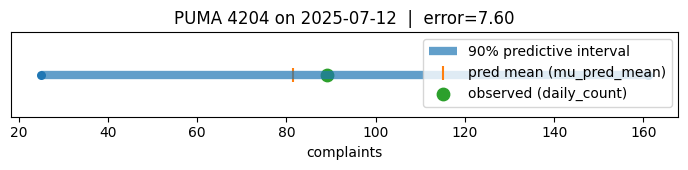

In [88]:
import matplotlib.pyplot as plt
import numpy as np

def plot_puma_day_interval(df, puma, date):
    r = inspect_puma_day(df, puma, date)

    # If multiple rows exist, just plot the first one
    rr = r.iloc[0]

    y = float(rr["daily_count"])
    mu = float(rr["mu_pred_mean"]) if "mu_pred_mean" in rr else np.nan
    lo = float(rr["y_pred_low_90"]) if "y_pred_low_90" in rr else np.nan
    hi = float(rr["y_pred_high_90"]) if "y_pred_high_90" in rr else np.nan

    plt.figure(figsize=(7, 1.8))
    # Interval
    if np.isfinite(lo) and np.isfinite(hi):
        plt.hlines(0, lo, hi, linewidth=6, alpha=0.7, label="90% predictive interval")
        plt.scatter([lo, hi], [0, 0], s=30)

    # Mean
    if np.isfinite(mu):
        plt.scatter([mu], [0], s=90, marker="|", label="pred mean (mu_pred_mean)")

    # Observed
    plt.scatter([y], [0], s=80, label="observed (daily_count)")

    plt.yticks([])
    plt.xlabel("complaints")
    plt.title(f"PUMA {str(puma)} on {pd.to_datetime(date).date()}  |  error={y-mu:.2f}")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

# Example:
plot_puma_day_interval(scored_2025, puma="4204", date=target_date)


In [45]:
import pandas as pd
import numpy as np

def summarize_model_performance(
    df: pd.DataFrame,
    *,
    abs_error_col: str = "abs_error",
    coverage_col: str | None = None,
) -> dict:
    """
    Compute MAE, Median AE, and 90% coverage from a comparison dataframe.
    """
    if coverage_col is None:
        # auto-detect coverage column
        if "within_90" in df.columns:
            coverage_col = "within_90"
        elif "within_90_lam" in df.columns:
            coverage_col = "within_90_lam"
        else:
            raise ValueError("No coverage column found")

    return {
        "MAE": float(df[abs_error_col].mean()),
        "Median AE": float(df[abs_error_col].median()),
        "90% Coverage": float(df[coverage_col].mean()),
    }


# def compare_models_side_by_side(
#     *,
#     old_df: pd.DataFrame,
#     new_df: pd.DataFrame,
#     old_label: str = "Old model",
#     new_label: str = "New model",
# ) -> pd.DataFrame:
#     """
#     Return a tidy side-by-side comparison table.
#     """
#     old_stats = summarize_model_performance(old_df)
#     new_stats = summarize_model_performance(new_df)

#     tbl = (
#         pd.DataFrame.from_dict(
#             {
#                 old_label: old_stats,
#                 new_label: new_stats,
#             },
#             orient="index",
#         )
#         .reset_index()
#         .rename(columns={"index": "Model"})
#     )

#     return tbl


import numpy as np
import pandas as pd

def summarize_model_performance(df: pd.DataFrame) -> dict:
    """
    Summarize performance for either:
      - Poisson "typical week" outputs:
          observed_2025, lam_forecast, lam_low_90, lam_high_90  (or within_90)
      - NB daily predictive outputs:
          daily_count, mu_pred_mean, y_pred_low_90, y_pred_high_90 (or within_90_pred)

    Returns a dict with:
      MAE, Median AE, 90% Coverage
    """

    # -----------------------------
    # Choose observed column
    # -----------------------------
    if "daily_count" in df.columns:
        y_obs = df["daily_count"].to_numpy()
    elif "observed_2025" in df.columns:
        y_obs = df["observed_2025"].to_numpy()
    else:
        raise KeyError("Need either 'daily_count' or 'observed_2025' in df.")

    # -----------------------------
    # Choose point prediction column
    # -----------------------------
    if "mu_pred_mean" in df.columns:
        y_hat = df["mu_pred_mean"].to_numpy()
    elif "lam_forecast" in df.columns:
        y_hat = df["lam_forecast"].to_numpy()
    else:
        raise KeyError("Need either 'mu_pred_mean' or 'lam_forecast' in df.")

    abs_err = np.abs(y_obs - y_hat)

    # -----------------------------
    # Choose 90% interval coverage
    # -----------------------------
    # Prefer predictive interval coverage if present
    if "within_90_pred" in df.columns:
        coverage = df["within_90_pred"].mean()
    elif {"y_pred_low_90", "y_pred_high_90"}.issubset(df.columns):
        coverage = ((y_obs >= df["y_pred_low_90"]) & (y_obs <= df["y_pred_high_90"])).mean()
    # Fall back to Poisson lam interval (rate interval) if that's all we have
    elif "within_90" in df.columns:
        coverage = df["within_90"].mean()
    elif {"lam_low_90", "lam_high_90"}.issubset(df.columns):
        coverage = ((y_obs >= df["lam_low_90"]) & (y_obs <= df["lam_high_90"])).mean()
    else:
        coverage = np.nan  # not computable

    return {
        "MAE": float(np.mean(abs_err)),
        "Median AE": float(np.median(abs_err)),
        "90% Coverage": float(coverage) if pd.notna(coverage) else np.nan,
        "N": int(len(df)),
    }


In [51]:
# comparison_table = compare_models_side_by_side(
#     old_df=cmp_2025_model3,   # Poisson
#     new_df=cmp_2025_model4,   # Negative Binomial
#     old_label="Model 3 (NTA pooled, Poisson)",
#     new_label="Model 4 (NTA pooled + NB)",
# )

comparison_table = compare_models_side_by_side(
    old_df=cmp_2025_model3,
    new_df=scored_2025,
    old_label="Model 3 (NTA pooled, Poisson)",
    new_label="Model 4 (NTA pooled + NB)",
)


display(comparison_table)



,Model,MAE,Median AE,90% Coverage,N
0,"Model 3 (NTA pooled, Poisson)",4.787839,2.862047,0.205195,385
1,Model 4 (NTA pooled + NB),9.543930,6.023554,0.915770,4832


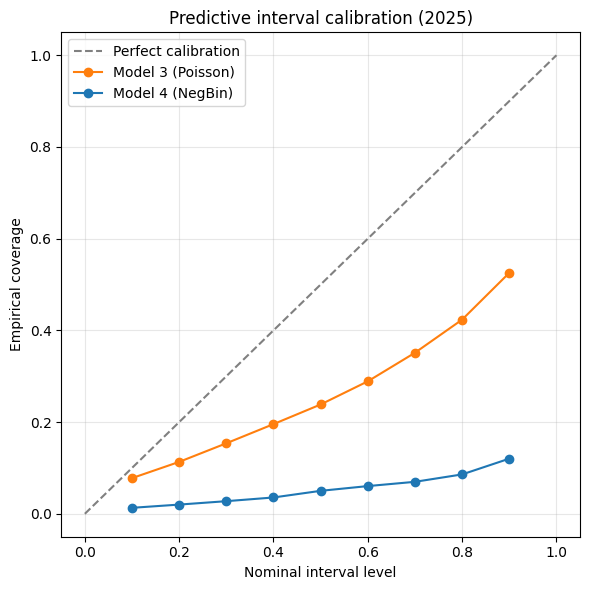

In [52]:


plt.figure(figsize=(6, 6))

# Diagonal = perfect calibration
x = np.linspace(0, 1, 100)
plt.plot(x, x, "--", color="gray", label="Perfect calibration")

# IMPORTANT: y_obs must align with y_pp rows
y_obs_m3 = daily_cmp_2025_model3["daily_count"].to_numpy()
y_obs_m4 = daily_cmp_2025_model4["daily_count"].to_numpy()

# Sanity checks
assert y_pp_model3.shape[0] == len(y_obs_m3), (y_pp_model3.shape, len(y_obs_m3))
assert y_pp_model4.shape[0] == len(y_obs_m4), (y_pp_model4.shape, len(y_obs_m4))

plot_coverage_curve(
    y_obs=y_obs_m3,
    y_pp=y_pp_model3,     # Poisson predictive draws
    label="Model 3 (Poisson)",
    color="C1",
)

plot_coverage_curve(
    y_obs=y_obs_m4,
    y_pp=y_pp_model4,     # NegBin predictive draws
    label="Model 4 (NegBin)",
    color="C0",
)

plt.xlabel("Nominal interval level")
plt.ylabel("Empirical coverage")
plt.title("Predictive interval calibration (2025)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
